<a href="https://colab.research.google.com/github/harjussingh/TIRP-Team02/blob/main/Symptom_Severness_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
INPUT_CSV = "/content/drive/MyDrive/Dataset/Symptoms and diseases dataset.csv"
df = pd.read_csv(INPUT_CSV)

In [ ]:
DISEASE_COL = 'disease'

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Older exports used "diseases"; disease_dataset.csv uses "disease"
if DISEASE_COL not in df.columns and 'diseases' in df.columns:
    df = df.rename(columns={'diseases': DISEASE_COL})

if DISEASE_COL not in df.columns:
    raise ValueError(f"Column '{DISEASE_COL}' not found in CSV")

# Clean text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

df = df.dropna()
df = df.drop_duplicates()

In [ ]:
min_samples = 50
df = df[df[DISEASE_COL].map(df[DISEASE_COL].value_counts()) >= min_samples]


In [ ]:
disease_counts = df[DISEASE_COL].value_counts().reset_index()
disease_counts.columns = ['disease_name', 'row_count']


In [ ]:
unique_diseases = df[DISEASE_COL].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)


Total unique diseases: 413
['panic disorder' 'atrophic vaginitis' 'fracture of the hand'
 'cellulitis or abscess of mouth' 'eye alignment disorder'
 'headache after lumbar puncture' 'vaginitis' 'sick sinus syndrome'
 'tinnitus of unknown cause' 'glaucoma' 'eating disorder'
 'transient ischemic attack' 'pyelonephritis' 'chronic pain disorder'
 'problem during pregnancy' 'injury to the hand' 'choledocholithiasis'
 'cirrhosis' 'thoracic aortic aneurysm' 'diabetic retinopathy'
 'fibromyalgia' 'ischemia of the bowel' 'peritonitis' 'acute pancreatitis'
 'thrombophlebitis' 'asthma' 'restless leg syndrome' 'induced abortion'
 'teething syndrome' 'infectious gastroenteritis' 'acute sinusitis'
 'substance-related mental disorder' 'postpartum depression'
 'coronary atherosclerosis' 'spondylitis' 'uterine fibroids' 'chalazion'
 'vaginal yeast infection' 'ingrown toe nail' 'pulmonary eosinophilia'
 'corneal disorder' 'intestinal malabsorption' 'viral warts' 'stroke'
 'pilonidal cyst' 'alopecia' 'pe

## Cell 1 — The Curated Disease Dictionary
Each entry: `'disease_name_exact_as_in_csv': ats_level`

**ATS Levels:**
- `1` = Resuscitation (Immediate)
- `2` = Emergency (≤10 min)
- `3` = Urgent (≤30 min)
- `4` = Semi-Urgent (≤60 min)
- `5` = Non-Urgent (≤120 min)



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  SELECTED DISEASE LIST — Indigenous Australian Clinical Triage System
#
#  Disease names below are EXACT matches to your disease_list.txt
#  Format: 'disease name as in csv' : ATS_level (1=most urgent, 5=least)
# ══════════════════════════════════════════════════════════════════════════════
SELECTED_DISEASES = {

    # 🔴 ATS 1 — CRITICAL
    "heart attack": 1,
    "cardiac arrest": 1,
    "stroke": 1,
    "sepsis": 1,
    "meningitis": 1,

    # 🟠 ATS 2 — EMERGENCY
    "pulmonary embolism": 2,
    "appendicitis": 2,
    "acute pancreatitis": 2,
    "ectopic pregnancy": 2,
    "gastrointestinal hemorrhage": 2,
    "acute kidney injury": 2,
    "preeclampsia": 2,
    "peritonitis": 2,
    "alcohol withdrawal": 2,

    # 🟡 ATS 3 — URGENT
    "pneumonia": 3,
    "asthma": 3,
    "chronic obstructive pulmonary disease (copd)": 3,
    "pyelonephritis": 3,
    "kidney stone": 3,
    "cholecystitis": 3,
    "angina": 3,
    "deep vein thrombosis (dvt)": 3,
    "diverticulitis": 3,
    "acute sinusitis": 3,
    "acute bronchitis": 3,
    "acute bronchiolitis": 3,
    "intestinal obstruction": 3,
    "liver disease": 3,
    "cirrhosis": 3,
    "fracture of the leg": 3,
    "fracture of the arm": 3,
    "fracture of the rib": 3,
    "concussion": 3,
    "pneumothorax": 3,
    "atrial fibrillation": 3,
    "pericarditis": 3,
    "encephalitis": 3,
    "endocarditis": 3,
    "osteomyelitis": 3,
    "septic arthritis": 3,
    "strep throat": 3,
    "hyperemesis gravidarum": 3,

    # 🔵 ATS 4 — SEMI-URGENT (COMMON GP)
    "urinary tract infection": 4,
    "otitis media": 4,
    "conjunctivitis": 4,
    "cataract": 4,
    "glaucoma": 4,
    "hypertension": 4,
    "diabetes": 4,
    "anxiety": 4,
    "depression": 4,
    "panic disorder": 4,
    "chronic back pain": 4,
    "osteoarthritis": 4,
    "rheumatoid arthritis": 4,
    "gout": 4,
    "eczema": 4,
    "contact dermatitis": 4,
    "psoriasis": 4,
    "scabies": 4,
    "impetigo": 4,
    "fungal infection of the skin": 4,
    "iron deficiency anemia": 4,
    "gastritis": 4,
    "gastroesophageal reflux disease (gerd)": 4,
    "infectious gastroenteritis": 4,
    "tonsillitis": 4,
    "cystitis": 4,
    "prostatitis": 4,
    "pelvic inflammatory disease": 4,
    "chlamydia": 4,
    "gonorrhea": 4,
    "multiple sclerosis": 4,
    "epilepsy": 4,
    "migraine": 4,
    "tension headache": 4,
    "fibromyalgia": 4,
    "hypothyroidism": 4,
    "polycystic ovarian syndrome (pcos)": 4,
    "endometriosis": 4,
    "ovarian cyst": 4,
    "smoking or tobacco addiction": 4,
    "alcohol abuse": 4,
    "drug abuse": 4,
    "attention deficit hyperactivity disorder (adhd)": 4,
    "autism": 4,
    "dementia": 4,
    "parkinson disease": 4,

    # 🟢 ATS 5 — COMMON / MILD (VERY IMPORTANT)
    "common cold": 5,
    "flu": 5,
    "viral infection": 5,
    "upper respiratory infection": 5,
    "food poisoning": 5,
    "seasonal allergies (hay fever)": 5,
    "allergy": 5,
    "hemorrhoids": 5,
    "chronic constipation": 5,
    "irritable bowel syndrome": 5,
    "dental caries": 5,
    "gum disease": 5,
    "acne": 5,
    "seborrheic dermatitis": 5,
    "insect bite": 5,
    "varicose veins": 5,
    "osteoporosis": 5,
    "macular degeneration": 5,
    "dry eye of unknown cause": 5
}

ATS_LABELS = {
    1: 'Resuscitation',
    2: 'Emergency',
    3: 'Urgent',
    4: 'Semi-Urgent',
    5: 'Non-Urgent',
}

df = df[df[DISEASE_COL].isin(SELECTED_DISEASES.keys())]

df["ats_level"] = df[DISEASE_COL].map(SELECTED_DISEASES)

df["ats_label"] = df["ats_level"].map(ATS_LABELS)


In [ ]:
filtered_df = df[df[DISEASE_COL].isin(SELECTED_DISEASES.keys())].drop_duplicates()

print(filtered_df[DISEASE_COL].nunique())
print(filtered_df[DISEASE_COL].value_counts())

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df[DISEASE_COL].unique())
print(f"Missing diseases: {len(missing)}")

95
diseases
cystitis                       1219
diverticulitis                 1214
gastrointestinal hemorrhage    1214
acute bronchitis               1213
pneumonia                      1212
                               ... 
deep vein thrombosis (dvt)       89
scabies                          83
osteomyelitis                    75
atrial fibrillation              68
epilepsy                         56
Name: count, Length: 95, dtype: int64
Missing diseases: 12


In [ ]:
filtered_df = filtered_df.dropna()

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df[DISEASE_COL].unique())
extra = set(df[DISEASE_COL].unique()) - set(SELECTED_DISEASES.keys())

print(f"Missing diseases: {len(missing)}")
print(f"Unmapped diseases: {len(extra)}")


Missing diseases: 12
Unmapped diseases: 0


In [ ]:
filtered_df.shape

(60671, 380)

In [ ]:
symptom_cols = [col for col in filtered_df.columns if col != DISEASE_COL]

for col in symptom_cols:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce').fillna(0)

useful_symptoms = [col for col in symptom_cols if filtered_df[col].sum() > 0]


In [ ]:
unique_diseases = filtered_df[DISEASE_COL].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)


Total unique diseases: 95
['panic disorder' 'glaucoma' 'pyelonephritis' 'cirrhosis' 'fibromyalgia'
 'peritonitis' 'acute pancreatitis' 'asthma' 'infectious gastroenteritis'
 'acute sinusitis' 'stroke' 'fracture of the arm' 'atrial fibrillation'
 'chronic obstructive pulmonary disease (copd)'
 'deep vein thrombosis (dvt)'
 'attention deficit hyperactivity disorder (adhd)' 'endometriosis'
 'concussion' 'gastroesophageal reflux disease (gerd)' 'allergy'
 'varicose veins' 'fungal infection of the skin' 'parkinson disease'
 'gout' 'otitis media' 'acute kidney injury' 'gum disease'
 'gastrointestinal hemorrhage' 'seborrheic dermatitis' 'tension headache'
 'anxiety' 'osteoarthritis' 'macular degeneration' 'pneumonia'
 'fracture of the rib' 'ectopic pregnancy' 'alcohol abuse' 'kidney stone'
 'autism' 'dental caries' 'polycystic ovarian syndrome (pcos)'
 'alcohol withdrawal' 'seasonal allergies (hay fever)'
 'dry eye of unknown cause' 'heart attack' 'fracture of the leg'
 'psoriasis' 'osteoporo

# ***Splitting into training and testing data***

In [ ]:
from sklearn.model_selection import train_test_split

X = filtered_df.drop(DISEASE_COL, axis=1)
y = filtered_df[DISEASE_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
print(filtered_df[DISEASE_COL].value_counts())


diseases
cystitis                       1219
diverticulitis                 1214
gastrointestinal hemorrhage    1214
acute bronchitis               1213
pneumonia                      1212
                               ... 
deep vein thrombosis (dvt)       89
scabies                          83
osteomyelitis                    75
atrial fibrillation              68
epilepsy                         56
Name: count, Length: 95, dtype: int64


# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)

# Detailed evaluation (recommended)
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.919241862381541

Classification Report:

                                                 precision    recall  f1-score   support

                                           acne       0.99      0.99      0.99        70
                            acute bronchiolitis       0.97      0.94      0.95       246
                               acute bronchitis       0.94      0.57      0.71       239
                            acute kidney injury       1.00      0.93      0.97       151
                             acute pancreatitis       0.98      0.98      0.98       249
                                acute sinusitis       1.00      0.94      0.97       163
                                  alcohol abuse       0.85      0.89      0.87        62
                             alcohol withdrawal       0.99      0.99      0.99        95
                                        allergy       0.94      0.96      0.95       154
                                         a

# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9269056448290071


# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9542645241038319


# Extra Trees Classifier

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)
et_acc = accuracy_score(y_test, et_preds)

print("Extra Trees Accuracy:", et_acc)

In [ ]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9254779957145212
Test Accuracy: 0.919241862381541


In [ ]:
results = {
    "Random Forest": rf_acc,
    "Extra Trees": et_acc,
    "Naive Bayes": nb_acc,
    "Decision Tree": dt_acc
}

print("\nModel Accuracy Comparison:\n")

print("{:<20} {:<10}".format("Model", "Accuracy"))
print("-" * 30)

for model, acc in results.items():
    print("{:<20} {:.4f}".format(model, acc))


Model Accuracy Comparison:

Model                Accuracy  
------------------------------
Random Forest        0.9192
Extra Trees          0.9369
Naive Bayes          0.9543
Decision Tree        0.9269


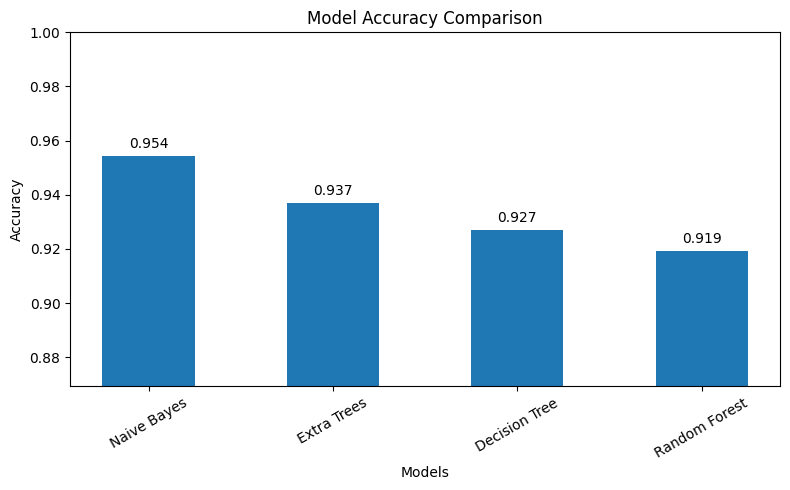

In [ ]:
import matplotlib.pyplot as plt

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

models = list(sorted_results.keys())
accuracies = list(sorted_results.values())

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        f"{yval:.3f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(min(accuracies) - 0.05, 1.0)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np

class EnsembleModel:
    def __init__(self, models, weights, voting='hard'):
        self.models = models
        self.weights = weights
        self.voting = voting

    def predict(self, X):
        if self.voting == 'soft':
            return self._soft_voting(X)
        else:
            return self._hard_voting(X)

    def _hard_voting(self, X):
        model_preds = {
            name: model.predict(X)
            for name, model in self.models.items()
        }

        final_preds = []

        for i in range(len(X)):
            votes = {}

            for name, preds in model_preds.items():
                pred = preds[i]
                weight = self.weights.get(name, 1)

                votes[pred] = votes.get(pred, 0) + weight

            final_pred = max(votes, key=votes.get)
            final_preds.append(final_pred)

        return np.array(final_preds)

    def _soft_voting(self, X):
        total_weight = sum(self.weights.values())
        weighted_probs = None

        for name, model in self.models.items():
            if not hasattr(model, "predict_proba"):
                raise ValueError(f"{name} does not support predict_proba")

            probs = model.predict_proba(X)
            weight = self.weights.get(name, 1)

            if weighted_probs is None:
                weighted_probs = weight * probs
            else:
                weighted_probs += weight * probs

        weighted_probs /= total_weight

        return np.argmax(weighted_probs, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model
}

weights = {
    "Random Forest": 1,
    "Extra Trees": 2,
    "Naive Bayes": 4,
    "Decision Tree": 1
}

In [ ]:
ensemble_model = EnsembleModel(models, weights)

ensemble_preds = ensemble_model.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))
print("Ensemble F1 Score:", f1_score(y_test, ensemble_preds, average='weighted'))

Now we will start testing the application, with a sample scenario, now will have user give some symptoms, the the model will try to make a prediction, if the model is not able to make a accurate prediction it will ask up on follow-up questions

In [ ]:
ATS5_DISEASES = [d for d, level in SELECTED_DISEASES.items() if level == 5]
ATS4_DISEASES = [d for d, level in SELECTED_DISEASES.items() if level == 4]
MILD_DISEASES = set(ATS5_DISEASES) | set(ATS4_DISEASES)

all_symptoms = X.columns.tolist()
symptom_index = {s: i for i, s in enumerate(all_symptoms)}

COMMON_MISTAKES = {
    "vomitting": "vomiting",
    "feaver": "fever",
    "diarrhoea": "diarrhea",
}

# Map typed phrases (spaces) → column names (underscores), same idea as the mobile/desktop apps
SYMPTOM_ALIASES = {
    "runny nose": "runny_nose",
    "sore throat": "sore_throat",
    "mild fever": "mild_fever",
    "mild cough": "mild_cough",
    "mild headache": "mild_headache",
    "chest pain": "chest_pain",
    "shortness of breath": "shortness_of_breath",
    "difficulty breathing": "difficulty_breathing",
    "abdominal pain": "abdominal_pain",
    "belly pain": "abdominal_pain",
    "blood in urine": "blood_in_urine",
    "high fever": "high_fever",
}

CRITICAL_DISEASES = {
    "sepsis", "meningitis", "heart attack",
    "stroke", "cardiac arrest",
}

# Do not suggest these as follow-ups when the user already looks like a mild case
EMERGENCY_FOLLOWUP_SYMPTOMS = {
    "collapse", "loss_of_consciousness", "cyanosis", "not_breathing",
    "absent_pulse", "no_pulse", "unresponsive", "continuous_seizure",
    "crushing_chest_pain", "facial_drooping", "slurred_speech",
    "vomiting_blood", "coughing_blood",
}

SYMPTOM_FAMILY = {
    "fever": "fever", "mild_fever": "fever", "high_fever": "fever",
    "cough": "cough", "mild_cough": "cough", "productive_cough": "cough",
    "runny_nose": "nose", "nasal_congestion": "nose",
    "sore_throat": "throat", "severe_throat_pain": "throat",
    "headache": "headache", "mild_headache": "headache", "severe_headache": "headache",
    "chest_pain": "chest", "severe_chest_pain": "chest", "crushing_chest_pain": "chest",
    "shortness_of_breath": "breathing", "difficulty_breathing": "breathing",
    "severe_difficulty_breathing": "breathing", "wheezing": "breathing",
    "nausea": "nausea", "vomiting": "vomiting", "diarrhea": "diarrhea",
    "abdominal_pain": "abdomen", "severe_abdominal_pain": "abdomen",
    "fatigue": "fatigue", "body_aches": "body",
}


def _token_to_column(token: str) -> str:
    token = token.strip().lower().replace("-", " ")
    token = COMMON_MISTAKES.get(token, token)
    if token in SYMPTOM_ALIASES:
        return SYMPTOM_ALIASES[token]
    return token.replace(" ", "_")


def normalize(symptoms):
    out = []
    for s in symptoms:
        col = _token_to_column(s)
        if col in symptom_index and col not in out:
            out.append(col)
    return out


def _symptom_family(symptom: str) -> str:
    return SYMPTOM_FAMILY.get(symptom, symptom.split("_")[0] if "_" in symptom else symptom)


def _format_symptom(symptom: str) -> str:
    return symptom.replace("_", " ")


COLD_LIKE_SYMPTOMS = {
    "mild_fever", "fever", "mild_cough", "cough", "runny_nose", "sore_throat",
    "nasal_congestion", "sneezing", "fatigue", "body_aches",
}

# ATS 5 illnesses that match a classic cold/flu picture (not acute bronchitis etc.)
RESPIRATORY_MILD_DISEASES = {
    "common cold", "flu", "viral infection",
}


def _cold_like_count(symptoms) -> int:
    return len(set(symptoms) & COLD_LIKE_SYMPTOMS)


def _is_mild_presentation(symptoms) -> bool:
    if any(s in EMERGENCY_FOLLOWUP_SYMPTOMS for s in symptoms):
        return False
    if any(s.startswith("mild_") for s in symptoms):
        return True
    return _cold_like_count(symptoms) >= 2


def _best_mild_respiratory(symptoms):
    """When symptoms already look like a cold, pick among mild URI labels (not ATS-3 bronchitis)."""
    input_df = create_input(symptoms)
    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    best_name, best_p = None, 0.0
    for i, name in enumerate(classes):
        if name in RESPIRATORY_MILD_DISEASES and probs[i] > best_p:
            best_name, best_p = name, float(probs[i])

    if best_name and best_p >= 0.05:
        return best_name, best_p

    # Classic 4-symptom cold bundle: safe default when ensemble favours ATS-3 lookalikes
    if _cold_like_count(symptoms) >= 4:
        return "common cold", max(best_p, 0.30)

    return None, None


def _needs_follow_up(symptoms) -> bool:
    """Skip extra questions when the user already gave a complete mild cold picture."""
    if not _is_mild_presentation(symptoms):
        return True
    if _cold_like_count(symptoms) >= 4:
        return False
    if _cold_like_count(symptoms) >= 3:
        _, conf = _best_mild_respiratory(symptoms)
        return conf is None or conf < 0.12
    return True


def create_input(symptom_list):
    input_vector = [0] * len(all_symptoms)
    for s in normalize(symptom_list):
        input_vector[symptom_index[s]] = 1
    return pd.DataFrame([input_vector], columns=all_symptoms)

# =========================
# ENSEMBLE
# =========================

def ensemble_predict_proba(input_df):
    probs = None
    total_weight = 9

    model_probs = [
        (rf_model.predict_proba(input_df), 1),
        (et_model.predict_proba(input_df), 2),
        (nb_model.predict_proba(input_df), 3),
        (dt_model.predict_proba(input_df), 1),
    ]

    for p, w in model_probs:
        if probs is None:
            probs = w * p
        else:
            probs += w * p

    probs /= total_weight
    return probs

# =========================
# PREDICTION
# =========================

def get_top_diseases(symptoms, top_n=3):
    input_df = create_input(symptoms)

    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    sorted_idx = np.argsort(probs)[::-1]
    results = [(classes[i], probs[i]) for i in sorted_idx]

    filtered = [
        (d, p) for d, p in results
        if not (d in CRITICAL_DISEASES and p < 0.3)
    ]

    if not filtered:
        filtered = results

    return sorted(filtered, key=lambda x: x[1], reverse=True)[:top_n]

def _context_followup_candidates(symptoms):
    """Same idea as saca-windows-app triage_orchestrator._context_followup_candidates."""
    families = {_symptom_family(s) for s in symptoms}
    candidates = []

    if families & {"fever", "cough", "throat", "body", "fatigue", "nose"}:
        candidates += ["difficulty_breathing", "chest_pain", "high_fever", "fatigue"]

    if families & {"abdomen", "vomiting", "diarrhea", "nausea"}:
        candidates += ["severe_abdominal_pain", "vomiting", "diarrhea", "fever"]

    if families & {"chest", "breathing"}:
        candidates += ["severe_chest_pain", "severe_difficulty_breathing", "dizziness"]

    if families & {"headache", "dizziness"}:
        candidates += ["severe_headache", "vomiting", "confusion"]

    if not candidates:
        candidates = ["fever", "cough", "difficulty_breathing"]

    return candidates


def _choose_followups(user_symptoms, diseases, df, top_n=3):
    user_set = set(user_symptoms)
    user_families = {_symptom_family(s) for s in user_set}
    mild = _is_mild_presentation(user_symptoms)
    selected = []

    for symptom in _context_followup_candidates(user_symptoms):
        if symptom not in symptom_index or symptom in user_set:
            continue
        if mild and symptom in EMERGENCY_FOLLOWUP_SYMPTOMS:
            continue
        family = _symptom_family(symptom)
        if family in user_families:
            continue
        if symptom in selected:
            continue
        selected.append(symptom)
        user_families.add(family)
        if len(selected) >= top_n:
            return selected

    # Optional: symptoms common in top predicted diseases, but only if still mild-safe
    disease_names = [d for d, _ in diseases if SELECTED_DISEASES.get(d, 99) >= 4]
    if disease_names:
        subset = df[df[DISEASE_COL].isin(disease_names)]
        symptom_cols = [c for c in df.columns if c not in (DISEASE_COL, "ats_level", "ats_label")]
        counts = subset[symptom_cols].sum().sort_values(ascending=False)
        for symptom in counts.index:
            if symptom in user_set or symptom not in symptom_index:
                continue
            if mild and symptom in EMERGENCY_FOLLOWUP_SYMPTOMS:
                continue
            family = _symptom_family(symptom)
            if family in user_families:
                continue
            if symptom in selected:
                continue
            selected.append(symptom)
            user_families.add(family)
            if len(selected) >= top_n:
                break

    return selected[:top_n]


def check_common_conditions(symptoms):
    symptoms = normalize(symptoms)
    if not symptoms:
        return None, None

    # Classic cold/flu symptom set → mild URI diseases (avoids acute bronchitis fast-path miss)
    if _cold_like_count(symptoms) >= 3 and _is_mild_presentation(symptoms):
        mild_uri, conf = _best_mild_respiratory(symptoms)
        if mild_uri:
            return mild_uri, conf

    input_df = create_input(symptoms)
    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    # Any ATS 4–5 disease in the top few predictions
    for i in np.argsort(probs)[::-1][:8]:
        d = classes[i]
        p = float(probs[i])
        if d in MILD_DISEASES and p >= 0.15:
            return d, p

    idx = np.argmax(probs)
    disease = classes[idx]
    confidence = float(probs[idx])

    if disease in MILD_DISEASES and confidence >= 0.25:
        return disease, confidence

    return None, None


def get_followup_questions(diseases, df, user_symptoms, top_n=3):
    user_symptoms = normalize(user_symptoms)
    return _choose_followups(user_symptoms, diseases, df, top_n=top_n)

# =========================
# MAIN SYSTEM
# =========================

def symptom_checker():
    user_input = input("Enter your symptoms (comma-separated): ")
    user_symptoms = normalize([s for s in user_input.split(",") if s.strip()])

    if not user_symptoms:
        print("\nNo recognized symptoms. Try phrases like: mild fever, cough, runny nose, sore throat")
        return None, None, []

    print("Recognized:", ", ".join(_format_symptom(s) for s in user_symptoms))

    disease, confidence = check_common_conditions(user_symptoms)

    if disease:
        ats = SELECTED_DISEASES.get(disease, "?")
        print(f"\nLikely condition: {disease} (confidence {confidence:.2f}, ATS {ats})")
        return disease, confidence, user_symptoms

    top = get_top_diseases(user_symptoms)
    print("\nA few more details will help narrow this down.")

    follow_up = get_followup_questions(top, filtered_df, user_symptoms)
    if follow_up:
        print("Do you also have any of these?")
        for s in follow_up:
            print(f"  - {_format_symptom(s)}")
    else:
        print("Press Enter if none apply, or type more symptoms below.")

    more = input("Additional symptoms (comma-separated, or Enter to skip): ").strip()

    if more:
        user_symptoms = normalize(user_symptoms + [s for s in more.split(",") if s.strip()])

    input_df = create_input(user_symptoms)
    probs = ensemble_predict_proba(input_df)[0]
    classes = rf_model.classes_

    idx = np.argmax(probs)
    final_pred = classes[idx]
    confidence = float(probs[idx])

    if confidence < 0.25:
        print("\nStill uncertain. Please consult a doctor.")
        return None, None, user_symptoms

    print(f"\nFinal prediction: {final_pred} (confidence {confidence:.2f})")
    return final_pred, confidence, user_symptoms

# =========================
# ATS OUTPUT
# =========================

def get_ats_output(disease, confidence):

    if confidence < 0.25:
        return "Unknown", "Low confidence. Please consult a GP."

    ats = SELECTED_DISEASES.get(disease, "Unknown")

    if ats == 1:
        advice = "Call emergency services immediately"
    elif ats == 2:
        advice = "Go to hospital immediately"
    elif ats == 3:
        advice = "Seek urgent medical care"
    elif ats == 4:
        advice = "Visit a GP"
    elif ats == 5:
        advice = "Self-care or routine check"
    else:
        advice = "Consult a healthcare provider"

    return ats, advice

# =========================
# RUN
# =========================

disease, confidence, symptoms = symptom_checker()

if disease:
    ats, advice = get_ats_output(disease, confidence)

    print("\nATS Level:", ats)
    print("Advice:", advice)



Symptoms unclear. Let's refine further...
Do you also have:
lacrimation, leg_pain, headache, ear_pain, frontal_headache

Final Prediction: meningitis (0.58)

ATS Level: 1
Advice: Call emergency services immediately


## Export `model.tflite` (used by Android & Windows apps)

The **mobile and desktop apps do not use** the sklearn disease ensemble above. They load:

| File | Purpose |
|------|---------|
| `model.tflite` | On-device neural network |
| `model_meta.json` | Output names, severity labels, input shape |
| `symptom_vocab.json` | Maps typed symptoms → model input indices |

**Model inputs:** multi-hot vector shape `(1, 234)` — one slot per symptom token (`None` at index 0).

**Model outputs (same as `test.py` and the apps):**

1. `confidence` — how sure the model is  
2. `needs_follow_up` — score ≥ 0.5 → app asks extra yes/no questions  
3. `severity` — `MILD`, `MODERATE`, or `NEEDS_REST`  
4. `suggested_symptoms` — extra symptoms to ask about (only if follow-up is needed)

**Training data:** `disease_dataset.csv` (symptom columns + `ats_level`).

Run the code cell below **once** to regenerate the three files in this folder. *(Leave unrun during a live demo if you only need to show the pipeline.)*

In [ ]:
# =============================================================================
# BUILD & EXPORT model.tflite  (SACA Android / Windows apps)
# =============================================================================
# Pipeline: disease_dataset.csv → Keras model → model.tflite + JSON sidecars
# Test after export:  python test.py

import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- paths (same folder as this notebook) ---
APP_DIR = Path(".").resolve()
CSV_PATH = APP_DIR / "disease_dataset.csv"
VOCAB_PATH = APP_DIR / "symptom_vocab.json"
META_PATH = APP_DIR / "model_meta.json"
TFLITE_PATH = APP_DIR / "model.tflite"

SEVERITY_ORDER = ["MILD", "MODERATE", "NEEDS_REST"]
INPUT_DIM = 234          # must match model_meta.json input_shape[1]
EPOCHS = 12              # increase for better quality (e.g. 25–40)
BATCH_SIZE = 64
VAL_SPLIT = 0.15
SEED = 42

META_COLS = {"disease", "ats_level", "ats_label", "advice"}


def ats_to_severity_idx(ats_level: int) -> int:
    """Map ATS 1–5 → class index for MILD / MODERATE / NEEDS_REST."""
    if ats_level <= 2:
        return 1   # MODERATE (emergency / hospital)
    if ats_level == 3:
        return 1   # MODERATE (urgent)
    if ats_level == 4:
        return 0   # MILD (GP)
    return 2       # NEEDS_REST (self-care)


def load_training_data():
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    if VOCAB_PATH.exists():
        vocab = json.loads(VOCAB_PATH.read_text(encoding="utf-8"))
    else:
        symptom_cols = [c for c in df.columns if c not in META_COLS]
        vocab = ["None"] + symptom_cols

    token_to_idx = {t: i for i, t in enumerate(vocab) if i < INPUT_DIM}

    symptom_cols = [c for c in df.columns if c not in META_COLS]
    X = np.zeros((len(df), INPUT_DIM), dtype=np.float32)
    for col in symptom_cols:
        idx = token_to_idx.get(col)
        if idx is None:
            continue
        X[:, idx] = pd.to_numeric(df[col], errors="coerce").fillna(0).values.astype(np.float32)

    # labels derived from ATS + symptom count (matches app triage idea)
    ats = df["ats_level"].astype(int).values
    active = X.sum(axis=1)

    y_severity = np.array([ats_to_severity_idx(a) for a in ats], dtype=np.int32)
    y_confidence = np.clip(0.92 - 0.08 * (ats - 1), 0.45, 0.95).astype(np.float32)
    y_followup = ((active < 3) | (ats <= 3)).astype(np.float32)

    # suggestion target: symptoms often seen in the dataset but not on this row
    y_suggest = np.zeros((len(df), INPUT_DIM), dtype=np.float32)
    for j in range(INPUT_DIM):
        if j >= len(vocab) or vocab[j].lower() == "none":
            continue
        col_rate = X[:, j].mean()
        y_suggest[:, j] = np.clip(col_rate * (1 - X[:, j]), 0, 1).astype(np.float32)

    return X, y_confidence, y_followup, y_severity, y_suggest, vocab


def build_model():
    inputs = keras.Input(shape=(INPUT_DIM,), name="symptoms")

    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)

    out_confidence = layers.Dense(1, activation="sigmoid", name="confidence")(x)
    out_followup = layers.Dense(1, activation="sigmoid", name="needs_follow_up")(x)
    out_severity = layers.Dense(len(SEVERITY_ORDER), activation="softmax", name="severity")(x)
    out_suggest = layers.Dense(INPUT_DIM, activation="sigmoid", name="suggested_symptoms")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=[out_confidence, out_followup, out_severity, out_suggest],
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss={
            "confidence": "mse",
            "needs_follow_up": "binary_crossentropy",
            "severity": "sparse_categorical_crossentropy",
            "suggested_symptoms": "binary_crossentropy",
        },
        loss_weights={
            "confidence": 1.0,
            "needs_follow_up": 1.0,
            "severity": 2.0,
            "suggested_symptoms": 0.5,
        },
        metrics={
            "severity": "accuracy",
            "needs_follow_up": "accuracy",
        },
    )
    return model


def export_tflite(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    converter._experimental_lower_tensor_list_ops = False
    tflite_model = converter.convert()
    TFLITE_PATH.write_bytes(tflite_model)
    print(f"Saved {TFLITE_PATH} ({len(tflite_model) / 1024:.1f} KB)")


def save_sidecars(vocab):
    VOCAB_PATH.write_text(json.dumps(vocab, indent=2), encoding="utf-8")
    meta = {
        "output_order": [
            "confidence",
            "needs_follow_up",
            "severity",
            "suggested_symptoms",
        ],
        "severity_order": SEVERITY_ORDER,
        "input_shape": [1, INPUT_DIM],
        "vocab_first_token": "None",
        "note": "Show suggested_symptoms only when needs_follow_up >= 0.5",
    }
    META_PATH.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Saved {VOCAB_PATH.name}, {META_PATH.name}")


# --- run export (set True when you actually want to retrain) ---
RUN_EXPORT = False
# RUN_EXPORT = True

if RUN_EXPORT:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    X, y_conf, y_follow, y_sev, y_sug, vocab = load_training_data()
    print(f"Training samples: {X.shape[0]:,}  |  input dim: {INPUT_DIM}  |  vocab tokens: {len(vocab)}")

    model = build_model()
    model.summary()

    history = model.fit(
        X,
        {
            "confidence": y_conf,
            "needs_follow_up": y_follow,
            "severity": y_sev,
            "suggested_symptoms": y_sug,
        },
        validation_split=VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )

    export_tflite(model)
    save_sidecars(vocab)

    print("\nDone. Copy these three files into:")
    print("  - saca-android-app/app/src/main/assets/")
    print("  - saca-windows-app-v3/models/ml/")
    print("Then run:  python test.py")
else:
    print("Export cell ready — set RUN_EXPORT = True to train and write model.tflite")


## Colab: test `model.tflite` (same pipeline as Android / Windows)

**Before running:** put these three files where Colab can read them:

- `model.tflite`
- `model_meta.json`
- `symptom_vocab.json`

**Option A — Google Drive:** upload them to a folder on Drive, mount Drive, then set `MODEL_DIR` below to that path.

**Option B — Upload to `/content`:** use Colab’s file upload and set `MODEL_DIR = Path("/content")`.

The next cell installs TensorFlow, loads the interpreter, and defines `run_tflite_round()` plus helpers.

**Follow-up simulation:** when `needs_follow_up_score ≥ 0.5`, the apps may ask extra questions. The scenario cells show a **second inference** after you add symptoms the user would answer **yes** to (clinically sensible extras — same as merging into the multi-hot vector before calling the model again).

Run the setup cell once, then run each scenario cell **in order**.


In [ ]:
# =============================================================================
# Colab TFLite inference (mirrors test.py + apps)
# =============================================================================

# !pip install -q tensorflow

import json
import re
from pathlib import Path
from difflib import get_close_matches

import numpy as np

# --- set this to the folder that contains the three ML files ---
MODEL_DIR = Path("/content/saca-machine-learning-app")

# If you use Drive after mounting:
# from google.colab import drive
# drive.mount("/content/drive")
# MODEL_DIR = Path("/content/drive/MyDrive/YourFolder/saca-machine-learning-app")

FOLLOW_UP_THRESHOLD = 0.5

SYMPTOM_PHRASE_MAP = {
    "none": "None",
    "fever": "fever",
    "mild fever": "mild_fever",
    "high fever": "high_fever",
    "chills": "chills",
    "cough": "cough",
    "mild cough": "mild_cough",
    "productive cough": "productive_cough",
    "runny nose": "runny_nose",
    "nasal congestion": "nasal_congestion",
    "sore throat": "sore_throat",
    "fatigue": "fatigue",
    "body aches": "body_aches",
    "headache": "headache",
    "mild headache": "mild_headache",
    "severe headache": "severe_headache",
    "nausea": "nausea",
    "vomiting": "vomiting",
    "vomit": "vomiting",
    "diarrhea": "diarrhea",
    "diarrhoea": "diarrhea",
    "abdominal pain": "abdominal_pain",
    "stomach pain": "abdominal_pain",
    "severe abdominal pain": "severe_abdominal_pain",
    "chest pain": "chest_pain",
    "crushing chest pain": "crushing_chest_pain",
    "severe chest pain": "severe_chest_pain",
    "shortness of breath": "shortness_of_breath",
    "difficulty breathing": "difficulty_breathing",
    "severe difficulty breathing": "severe_difficulty_breathing",
    "wheezing": "wheezing",
    "not breathing": "not_breathing",
    "dizziness": "dizziness",
    "sweating": "sweating",
    "confusion": "confusion",
    "collapse": "collapse",
    "cyanosis": "cyanosis",
}


def _load_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))


def _pick_interpreter():
    for mod in (
        "tflite_runtime.interpreter",
        "tensorflow.lite.python.interpreter",
        "tensorflow.lite",
    ):
        try:
            Interpreter = __import__(mod, fromlist=["Interpreter"]).Interpreter
            return Interpreter
        except Exception:
            continue
    raise RuntimeError("Install TensorFlow or tflite-runtime")


class TFLiteRunner:
    def __init__(self, model_dir):
        self.model_dir = Path(model_dir)
        self.meta = _load_json(self.model_dir / "model_meta.json")
        self.vocab = _load_json(self.model_dir / "symptom_vocab.json")
        self.index = {t: i for i, t in enumerate(self.vocab)}
        self.input_size = int((self.meta.get("input_shape") or [1, len(self.vocab)])[1])
        self.output_order = list(self.meta.get("output_order") or [])
        self.severity_order = list(self.meta.get("severity_order") or ["MILD", "MODERATE", "NEEDS_REST"])

        Interpreter = _pick_interpreter()
        self.interpreter = Interpreter(model_path=str(self.model_dir / "model.tflite"))
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def normalize(self, phrase):
        key = (phrase or "").strip().lower().replace("-", " ").replace("_", " ")
        key = re.sub(r"\s+", " ", key).strip()
        if key in SYMPTOM_PHRASE_MAP:
            return SYMPTOM_PHRASE_MAP[key]
        unders = key.replace(" ", "_")
        if unders in self.index:
            return unders
        cand = [v for v in self.vocab if v.lower() != "none"]
        hit = get_close_matches(unders, cand, n=1, cutoff=0.86)
        return hit[0] if hit else unders

    def phrases_to_tokens(self, phrases):
        out = []
        for p in phrases:
            t = self.normalize(p)
            if t and t in self.index and t.lower() != "none" and t not in out:
                out.append(t)
        return out

    def vector(self, tokens):
        v = np.zeros((1, self.input_size), dtype=np.float32)
        if not tokens and "None" in self.index:
            v[0, self.index["None"]] = 1.0
            return v
        for t in tokens:
            j = self.index.get(t)
            if j is not None and j < self.input_size:
                v[0, j] = 1.0
        return v

    def _scalar(self, x, default):
        a = np.array(x, dtype=float).reshape(-1)
        if a.size == 0:
            return default
        return float(a[0] if a.size == 1 else a.max())

    def _severity(self, x):
        try:
            a = np.array(x).reshape(-1)
            idx = int(round(float(a[0]))) if a.size == 1 else int(np.argmax(a))
            if 0 <= idx < len(self.severity_order):
                return self.severity_order[idx].upper()
        except Exception:
            pass
        return "MILD"

    def suggestions(self, x, top_n=4):
        if x is None:
            return []
        arr = np.array(x).reshape(-1)
        out = []
        if arr.size == len(self.vocab):
            for idx in np.argsort(arr.astype(float))[::-1]:
                sym = self.vocab[int(idx)]
                sc = float(arr[int(idx)])
                if sym.lower() == "none" or sc <= 0.05:
                    if sc <= 0.05:
                        break
                    continue
                if sym not in out:
                    out.append(sym)
                if len(out) >= top_n:
                    break
            return out
        for raw in arr[:20]:
            idx = int(round(float(raw)))
            if 0 <= idx < len(self.vocab):
                sym = self.vocab[idx]
                if sym.lower() != "none" and sym not in out:
                    out.append(sym)
            if len(out) >= top_n:
                break
        return out

    def predict_from_phrases(self, phrases):
        tokens = self.phrases_to_tokens(phrases)
        vec = self.vector(tokens)
        self.interpreter.set_tensor(self.input_details[0]["index"], vec)
        self.interpreter.invoke()
        outs = [self.interpreter.get_tensor(d["index"]) for d in self.output_details]
        bag = {self.output_order[i]: outs[i] for i in range(min(len(self.output_order), len(outs)))}
        conf = self._scalar(bag.get("confidence"), 0.55)
        nfs = self._scalar(bag.get("needs_follow_up"), 0.0)
        sev = self._severity(bag.get("severity"))
        sug = self.suggestions(bag.get("suggested_symptoms"))
        need = nfs >= FOLLOW_UP_THRESHOLD
        if not need:
            sug = []
        return {
            "mapped_tokens": tokens,
            "confidence": conf,
            "needs_follow_up_score": nfs,
            "needs_follow_up": need,
            "severity": sev,
            "suggested_symptoms": sug,
        }


def _fmt(s):
    return str(s).replace("_", " ")


def print_round(label, phrases, r):
    print(f"\n=== {label} ===")
    print("Input phrases:", phrases)
    print("Mapped tokens:", r["mapped_tokens"] or ["(None only)"])
    print(f"  confidence:      {r['confidence']:.3f}")
    print(f"  needs_follow_up: {r['needs_follow_up_score']:.3f} → {r['needs_follow_up']} (threshold {FOLLOW_UP_THRESHOLD})")
    print(f"  severity:        {r['severity']}")
    if r["needs_follow_up"] and r["suggested_symptoms"]:
        print("  model suggested_symptoms:", ", ".join(_fmt(x) for x in r["suggested_symptoms"]))
    elif r["needs_follow_up"]:
        print("  model suggested_symptoms: (none above cutoff)")
    else:
        print("  model suggested_symptoms: (cleared — follow-up score below threshold)")


def run_two_step_demo(title, initial_phrases, followup_yes_phrases, explain=""):
    """First pass = user input. Second pass = same input + symptoms they answered YES to."""
    print("\n" + "#" * 72)
    print(f"# {title}")
    if explain:
        print(f"# {explain}")
    print("#" * 72)
    r1 = RUNNER.predict_from_phrases(initial_phrases)
    print_round("Round 1 — initial input (like first app screen)", initial_phrases, r1)
    if not followup_yes_phrases:
        print("\n(No second round — no extra symptoms added.)")
        return r1, None
    merged = list(initial_phrases) + list(followup_yes_phrases)
    print("\n--- Simulating follow-up: user answered YES to adding ---")
    print("   ", ", ".join(followup_yes_phrases))
    r2 = RUNNER.predict_from_phrases(merged)
    print_round("Round 2 — after yes to follow-up symptoms (like final assessment)", merged, r2)
    return r1, r2


# Create runner (re-run this cell if you change MODEL_DIR)
for _name in ("model.tflite", "model_meta.json", "symptom_vocab.json"):
    _p = MODEL_DIR / _name
    if not _p.is_file():
        raise FileNotFoundError(
            f"Missing {_p} — upload the three ML files or fix MODEL_DIR path."
        )
RUNNER = TFLiteRunner(MODEL_DIR)
print("TFLite OK —", MODEL_DIR.resolve())


In [ ]:
# Scenario 1 — Mild cold; follow-up: add fatigue
# Sparse cold picture first; second round adds tiredness the user confirms.
run_two_step_demo(
    """Scenario 1 — Mild cold; follow-up: add fatigue""",
    "mild fever, cough, runny nose, sore throat".split(", "),
    ['fatigue'],
    """Sparse cold picture first; second round adds tiredness the user confirms.""",
)



In [ ]:
# Scenario 2 — Sparse fever + cough; follow-up: high fever + difficulty breathing
# Mimics app asking for red-flag respiratory symptoms after a thin first input.
run_two_step_demo(
    """Scenario 2 — Sparse fever + cough; follow-up: high fever + difficulty breathing""",
    "fever, cough".split(", "),
    ['high fever', 'difficulty breathing'],
    """Mimics app asking for red-flag respiratory symptoms after a thin first input.""",
)



In [ ]:
# Scenario 3 — GI bug; follow-up: severe abdominal pain
# User reports worse belly pain on follow-up.
run_two_step_demo(
    """Scenario 3 — GI bug; follow-up: severe abdominal pain""",
    "abdominal pain, vomiting, diarrhea, nausea".split(", "),
    ['severe abdominal pain'],
    """User reports worse belly pain on follow-up.""",
)



In [ ]:
# Scenario 4 — Chest pressure; follow-up: dizziness
# Already serious cluster; second pass adds neuro symptom user confirms.
run_two_step_demo(
    """Scenario 4 — Chest pressure; follow-up: dizziness""",
    "crushing chest pain, shortness of breath, sweating, nausea".split(", "),
    ['dizziness'],
    """Already serious cluster; second pass adds neuro symptom user confirms.""",
)



In [ ]:
# Scenario 5 — Cough + breath + chest; follow-up: wheezing
# Airway narrowing added on follow-up.
run_two_step_demo(
    """Scenario 5 — Cough + breath + chest; follow-up: wheezing""",
    "cough, difficulty breathing, chest pain, fatigue".split(", "),
    ['wheezing'],
    """Airway narrowing added on follow-up.""",
)



In [ ]:
# Scenario 6 — Flu-like; follow-up: chills
# Classic flu picture; user confirms chills.
run_two_step_demo(
    """Scenario 6 — Flu-like; follow-up: chills""",
    "fever, cough, body aches, fatigue".split(", "),
    ['chills'],
    """Classic flu picture; user confirms chills.""",
)



In [ ]:
# Scenario 7 — Headache cluster; follow-up: severe headache + vomiting
# Worsening headache and vomiting on follow-up.
run_two_step_demo(
    """Scenario 7 — Headache cluster; follow-up: severe headache + vomiting""",
    "headache, dizziness, nausea".split(", "),
    ['severe headache', 'vomiting'],
    """Worsening headache and vomiting on follow-up.""",
)



In [ ]:
# Scenario 8 — Minimal ENT; follow-up: fever + productive cough
# Starts mild; user confirms infection-type symptoms.
run_two_step_demo(
    """Scenario 8 — Minimal ENT; follow-up: fever + productive cough""",
    "sore throat, mild cough".split(", "),
    ['fever', 'productive cough'],
    """Starts mild; user confirms infection-type symptoms.""",
)



In [ ]:
# Scenario 9 — Chest + cough only; follow-up: severe chest pain
# Escalation from generic chest + cough to severe pain.
run_two_step_demo(
    """Scenario 9 — Chest + cough only; follow-up: severe chest pain""",
    "chest pain, cough".split(", "),
    ['severe chest pain'],
    """Escalation from generic chest + cough to severe pain.""",
)



In [ ]:
# Scenario 10 — Single symptom; follow-up: confusion
# One strong finding; follow-up adds altered mental status.
run_two_step_demo(
    """Scenario 10 — Single symptom; follow-up: confusion""",
    "high fever".split(", "),
    ['confusion'],
    """One strong finding; follow-up adds altered mental status.""",
)

